# Random Forest Model

[Scikit Learn Source](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [1]:
import src.utils.utils as ut
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

In [2]:
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False,)
wine_df = wine_df.rename(columns={"index": "wine_id"})
wine_df

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Carlos,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,0,0,0,0,0,0,0
1,1,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2015.0,Catena Zapata,4.7,297.0,675.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0
2,2,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2017.0,Catena Zapata,4.7,219.0,580.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0
3,3,https://www.vivino.com/US/en/monteviejo-la-vio...,La Violeta,2013.0,Monteviejo,4.7,202.0,150.00,0.7306,0.4091,...,0,0,0,0,0,0,0,1,0,0
4,4,https://www.vivino.com/US/en/vina-cobos-cobos-...,Cobos Volturno,2018.0,Viña Cobos,4.7,198.0,399.99,0.7105,0.4563,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1950,1950,https://www.vivino.com/etchart-cafayate-terroi...,Cafayate Terroir de Altura Torrontés,2021.0,Bodegas Etchart,3.9,110.0,16.99,0.4789,0.3701,...,0,0,0,0,0,0,0,0,0,0
1951,1951,https://www.vivino.com/siesta-cabernet-sauvign...,Cabernet Sauvignon,2011.0,Siesta,3.9,108.0,23.63,0.6515,0.5417,...,0,0,0,0,0,0,0,0,0,0
1952,1952,https://www.vivino.com/gen-del-alma-jijiji-mal...,JIJIJI Malbec - Pinot Noir,2022.0,Gen del Alma,3.9,105.0,22.66,0.6311,0.4507,...,0,0,0,0,0,0,1,1,0,0
1953,1953,https://www.vivino.com/terrazas-de-los-andes-h...,High Altitude Vineyards Malbec,2021.0,Terrazas de los Andes,3.9,103.0,10.99,0.6266,0.3178,...,0,0,0,0,0,0,0,0,0,0


In [3]:
users_data = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_01_n1000.pkl"))
users_data = users_data.dropna()

In [4]:
recommend_df = pd.merge(wine_df, users_data, how="inner", on="wine_id")
recommend_df

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,user_id,user_input,metrics_local,metrics_global,liked,prob_like
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,0,335,"{'meal': 'Empanadas de Pollo', 'main_pairing':...",rating_rscld 2.5 price_rscld ...,rating_rscld_gbl 2.666667 price_rscl...,1.0,0.718536
1,11,https://www.vivino.com/US/en/catena-zapata-mal...,Malbec Argentino,2020.0,Catena Zapata,4.6,3695.0,66.67,0.6770,0.3338,...,0,0,0,0,391,"{'meal': 'Carne con Salsa de Champiñones', 'ma...",rating_rscld 1.5 price_rscld ...,rating_rscld_gbl 2.0 price_rscl...,0.0,0.832136
2,99,https://www.vivino.com/penedo-borges-penedo-bo...,Penedo Borges Icono Edicion Aniversario,2018.0,Otaviano,4.4,103.0,38.84,0.5033,0.4399,...,0,0,0,0,681,"{'meal': 'Roquefort con Nueces', 'main_pairing...",rating_rscld 1.2 price_rscld ...,rating_rscld_gbl 1.333333 price_rscl...,0.0,0.478363
3,107,https://www.vivino.com/vina-cobos-cocodrilo-re...,Cocodrilo Red Blend,2022.0,Viña Cobos,4.3,25.0,29.95,0.7195,0.4637,...,0,0,0,0,630,"{'meal': 'Asado', 'main_pairing': 'beef', 'pai...",rating_rscld 1.5 price_rscld ...,rating_rscld_gbl 1.0 price_rscl...,1.0,0.737391
4,107,https://www.vivino.com/vina-cobos-cocodrilo-re...,Cocodrilo Red Blend,2022.0,Viña Cobos,4.3,25.0,29.95,0.7195,0.4637,...,0,0,0,0,996,"{'meal': 'Guiso de Arroz con Carne', 'main_pai...",rating_rscld 0.5 price_rscld ...,rating_rscld_gbl 1.0 price_rscl...,1.0,0.855702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,1946,https://www.vivino.com/el-perseguidor-malbec-b...,Malbec - Bonarda,2015.0,El Perseguidor,3.9,25.0,14.99,0.6794,0.4844,...,0,0,0,0,375,"{'meal': 'Pechuga de Pollo Rellena', 'main_pai...",rating_rscld 0.25 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,0.0,0.803644
904,1946,https://www.vivino.com/el-perseguidor-malbec-b...,Malbec - Bonarda,2015.0,El Perseguidor,3.9,25.0,14.99,0.6794,0.4844,...,0,0,0,0,462,"{'meal': 'Matambre a la Pizza', 'main_pairing'...",rating_rscld 0.5 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,1.0,0.614450
905,1946,https://www.vivino.com/el-perseguidor-malbec-b...,Malbec - Bonarda,2015.0,El Perseguidor,3.9,25.0,14.99,0.6794,0.4844,...,0,0,0,0,562,"{'meal': 'Risotto de Champiñones', 'main_pairi...",rating_rscld 0.0 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,0.0,0.820370
906,1946,https://www.vivino.com/el-perseguidor-malbec-b...,Malbec - Bonarda,2015.0,El Perseguidor,3.9,25.0,14.99,0.6794,0.4844,...,0,0,0,0,845,"{'meal': 'Milanesa de Pollo', 'main_pairing': ...",rating_rscld 0.0 price_rscld ...,rating_rscld_gbl -0.333333 price_rscl...,1.0,0.888242


In [5]:
model_df = recommend_df.drop(columns=[
    "wine_id", "wine_link", "name", "winery", "style", "image",                        # Original df columns
    "user_id", "user_input", "metrics_local", "metrics_global", "prob_like" # User data columns
]).copy()
model_df

,year,rating,rating_qty,price,body,tannins,sweetness,acidity,alcohol,ageing,...,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,liked
0,2020.0,4.8,582.0,188.33,0.7343,0.5090,0.1361,0.4474,0.1410,0.0000,...,0,0,0,0,0,0,0,0,0,1.0
1,2020.0,4.6,3695.0,66.67,0.6770,0.3338,0.1996,0.3464,0.1350,0.0068,...,0,0,0,0,0,0,0,0,0,0.0
2,2018.0,4.4,103.0,38.84,0.5033,0.4399,0.3502,0.4387,0.1411,0.0000,...,0,0,0,0,0,0,0,0,0,0.0
3,2022.0,4.3,25.0,29.95,0.7195,0.4637,0.1676,0.4157,0.1470,0.0067,...,0,0,0,0,0,0,0,0,0,1.0
4,2022.0,4.3,25.0,29.95,0.7195,0.4637,0.1676,0.4157,0.1470,0.0067,...,0,0,0,0,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,2015.0,3.9,25.0,14.99,0.6794,0.4844,0.1597,0.5508,0.1366,0.0000,...,0,0,0,0,0,0,0,0,0,0.0
904,2015.0,3.9,25.0,14.99,0.6794,0.4844,0.1597,0.5508,0.1366,0.0000,...,0,0,0,0,0,0,0,0,0,1.0
905,2015.0,3.9,25.0,14.99,0.6794,0.4844,0.1597,0.5508,0.1366,0.0000,...,0,0,0,0,0,0,0,0,0,0.0
906,2015.0,3.9,25.0,14.99,0.6794,0.4844,0.1597,0.5508,0.1366,0.0000,...,0,0,0,0,0,0,0,0,0,1.0


In [6]:
X = model_df.drop(columns=["liked"])
y = model_df["liked"]
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X, y)
# Acá algo que va a pasar es que no hay un "bien y mal" clasificado. Todo depende de la probabilidad.
# Ahí deberíamos agarrar y poner como que un vino está OK clasificado si el 50%> de los usuarios respondieron que les gustó o que no.


RandomForestClassifier(random_state=0)

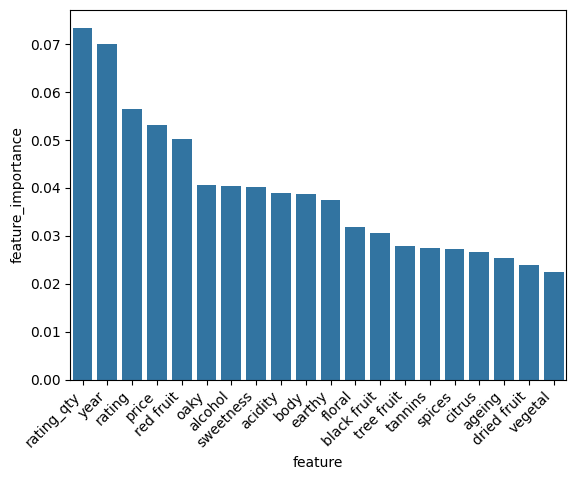

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

importances = model.feature_importances_
cols_importance = dict(zip(X.columns, importances))
cols_importance = pd.DataFrame(data=cols_importance.values(), index=cols_importance.keys(), columns=["feature_importance"]).sort_values(by="feature_importance", ascending=False)
cols_importance = cols_importance.reset_index(drop=False).rename(columns={"index": "feature"})

plt.figure()
sns.barplot(cols_importance[:20], x="feature", y="feature_importance")
plt.xticks(rotation=45, ha='right')
plt.show()


In [8]:
from src.models.synthetic_user import SyntheticUserSimulator
meals_df = pd.read_excel(ut.get_project_file_path("src", "data", "raw", "meals", "Meals.xlsx"))


user = SyntheticUserSimulator(
    wine_df=wine_df, meals_df=meals_df
)

user_input = user.generate_user_input()
user_input

{'meal': 'Tacos de Cerdo',
 'main_pairing': 'pork',
 'pairing_list': ['pork'],
 'grape_list': ['Malbec', 'Chardonnay'],
 'precio_min': 18,
 'precio_max': 27,
 'tastes': {'body': [np.float64(0.6634306569343067),
   np.float64(0.7178102189781023)],
  'tannins': [np.float64(0.3629270917406511), np.float64(0.4526499865482916)],
  'sweetness': [np.float64(0.5134180790960452), np.float64(1.0)],
  'acidity': [np.float64(0.041018387553041005),
   np.float64(0.3692619261926192)]},
 'tastes_label': {'body': 'marcado',
  'tannins': 'marcado',
  'sweetness': 'intenso',
  'acidity': 'leve'},
 'weights': {'rating': 0.25,
  'price_quality': 0.25,
  'rating_qty': 0.1,
  'user_similarity': 0.3,
  'main_pairing': 0.1}}

In [29]:
def filter_user_input(wine_df, user_input): 
    tra_df = wine_df.copy()
    tra_df = user._df_group_other_grapes(wine_df, drop=False)
    pairing_list = user_input["pairing_list"]
    grape_list = user_input["grape_list"]
    precio_min = user_input["precio_min"]
    precio_max = user_input["precio_max"]
    tra_df = tra_df[(tra_df["price"] >= precio_min) & (tra_df["price"] <= precio_max)]

    if pairing_list:
        pairing_filter = tra_df[pairing_list].eq(1).any(axis=1)
        tra_df = tra_df[pairing_filter]

    if grape_list:
        grape_filter = tra_df[grape_list].eq(1).any(axis=1)
        tra_df = tra_df[grape_filter]

    return tra_df


In [30]:
filtered_df = filter_user_input(wine_df, user_input)
filtered_df

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,Otras Uvas
112,112,https://www.vivino.com/alma-negra-m-blend/w/11...,M Blend,2019.0,Alma Negra,4.3,2639.0,23.99,0.6479,0.3816,...,0,0,0,0,0,0,0,0,0,1.0
113,113,https://www.vivino.com/el-enemigo-malbec/w/167...,Malbec,2021.0,El Enemigo,4.3,2519.0,25.00,0.6494,0.3528,...,0,0,0,0,0,0,0,0,0,0.0
122,122,https://www.vivino.com/alma-negra-m-blend/w/11...,M Blend,2020.0,Alma Negra,4.3,1093.0,22.95,0.6479,0.3816,...,0,0,0,0,0,0,0,0,0,1.0
183,183,https://www.vivino.com/el-enemigo-chardonnay/w...,Chardonnay,2019.0,El Enemigo,4.2,4239.0,23.00,0.5805,0.3045,...,0,0,0,0,0,0,0,0,0,0.0
184,184,https://www.vivino.com/el-enemigo-malbec/w/167...,Malbec,2020.0,El Enemigo,4.2,2873.0,25.00,0.6494,0.3528,...,0,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1938,1938,https://www.vivino.com/marchiori-malbec/w/1236...,Malbec,2023.0,Marchiori & Barraud,3.9,136.0,22.99,0.5799,0.3708,...,0,0,0,0,0,0,0,0,0,0.0
1941,1941,https://www.vivino.com/alta-vista-vive-malbec-...,Vive Malbec,2023.0,Alta Vista,3.9,137.0,20.00,0.4953,0.3173,...,0,0,0,0,0,0,0,0,0,0.0
1945,1945,https://www.vivino.com/alamos-seleccion-malbec...,Selección Malbec,2021.0,Alamos,3.9,127.0,19.94,0.6328,0.2547,...,0,0,0,0,0,0,0,0,0,0.0
1949,1949,https://www.vivino.com/durigutti-family-winema...,Durigutti Malbec,2021.0,Durigutti Family Winemakers,3.9,114.0,19.26,0.6269,0.2911,...,0,0,0,0,0,0,0,0,0,0.0


In [ ]:
# Bueno, acá llegamos a predecir si al usuario le gusta o no la recomendación, pero el problema es que hay muchas con prob 1 de que le guste...
# Eso es bien raro. Suena a overfitting. Revisar.

X_filtered = filtered_df[X.columns]
prob_like = model.predict_proba(X_filtered)[:, 1] # Index = 1 es probabilidad de que le guste la recomendación
filtered_df["prob_like"] = prob_like
filtered_df.sort_values(by="prob_like", ascending=False)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,Otras Uvas,prob_like
112,112,https://www.vivino.com/alma-negra-m-blend/w/11...,M Blend,2019.0,Alma Negra,4.3,2639.0,23.99,0.6479,0.3816,...,0,0,0,0,0,0,0,0,1.0,1.000000
377,377,https://www.vivino.com/clos-de-los-siete-clos-...,Clos de Los Siete (by Michel Rolland),2019.0,Clos de los Siete,4.0,7989.0,20.00,0.7262,0.4821,...,0,0,0,0,0,1,0,0,0.0,1.000000
264,264,https://www.vivino.com/d-v-catena-tinto-histor...,Tinto Historico,2019.0,D.V. Catena,4.1,2658.0,20.25,0.7110,0.4215,...,0,0,0,0,0,1,0,0,1.0,1.000000
260,260,https://www.vivino.com/renacer-milamore/w/5072...,Milamore,2019.0,Renacer,4.1,3640.0,24.98,0.6418,0.3790,...,0,0,0,0,0,0,0,0,1.0,1.000000
202,202,https://www.vivino.com/d-v-catena-tinto-histor...,Tinto Historico,2022.0,D.V. Catena,4.2,783.0,21.90,0.7110,0.4215,...,0,0,0,0,0,1,0,0,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
778,778,https://www.vivino.com/high-note-red-blend/w/3...,Red Blend,2020.0,High Note,3.8,61.0,18.89,0.6401,0.3526,...,0,0,0,0,0,1,0,0,0.0,0.318333
1257,1257,https://www.vivino.com/alma-negra-m-blend/w/11...,M Blend,2021.0,Alma Negra,4.3,769.0,22.99,0.6479,0.3816,...,0,0,0,0,0,0,0,0,1.0,0.310000
655,655,https://www.vivino.com/dona-paula-altitude-ser...,Altitude Series 1100 Red,2021.0,Doña Paula,3.8,25.0,21.99,0.6382,0.3772,...,0,0,0,0,0,1,0,0,0.0,0.304461
1726,1726,https://www.vivino.com/mascota-vineyards-unani...,Unánime Chardonnay,2022.0,Mascota Vineyards,4.0,119.0,22.97,0.5564,0.3045,...,0,0,0,0,0,0,0,0,0.0,0.300000
